 GRUPITÖÖ

INSTALLIMINE, ANDMETEGA HÄÄLESTAMINE/LUGEMINE

In [2]:
%pip install jinja2

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import duckdb as dd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
bolt_andmed = pd.read_csv("takso_andmed_clean.csv")


In [5]:
bolt_harjutus = bolt_andmed.copy()

In [6]:
bolt_andmed['order_id_new'].nunique()

4166

## Tellimuste arv

In [7]:
bolt_andmed.groupby('order_id_new').size().value_counts().sort_index()

1    3554
2     487
3      94
4      24
5       5
6       2
Name: count, dtype: int64

In [8]:
bolt_andmed["prediction_price_type"].value_counts(dropna=False)

prediction_price_type
upfront                        3432
prediction                     1279
upfront_destination_changed     208
NaN                              20
upfront_waypoint_changed          4
Name: count, dtype: int64

In [9]:
tabel = (
    bolt_andmed
    .dropna(subset=["prediction_price_type"])
    .groupby(["prediction_price_type", "overpaid_ride_ticket"])["order_id_new"]
    .nunique()
    .reset_index(name="sõidud")
)

tabel

,prediction_price_type,overpaid_ride_ticket,sõidud
0,prediction,0,860
1,prediction,1,203
2,upfront,0,2903
3,upfront,1,103
4,upfront_destination_changed,0,176
5,upfront_destination_changed,1,3
6,upfront_waypoint_changed,0,3


## Overcharge staatus = No Overcharge / Overcharge

In [10]:
bolt_andmed["overcharge_status"] = np.where(
    bolt_andmed["metered_price"] > bolt_andmed["upfront_price"],
    "OVERCHARGE",
    "NO OVERCHARGE"
)

## PÕHIANDMESTIKU TULPADE NIMISTIK

In [11]:
for col in bolt_andmed.columns:
    print(f"{col},")

order_id_new,
order_try_id_new,
calc_created,
metered_price,
upfront_price,
distance,
duration,
gps_confidence,
entered_by,
b_state,
dest_change_number,
prediction_price_type,
predicted_distance,
predicted_duration,
change_reason_pricing,
ticket_id_new,
rider_app_version,
order_state,
order_try_state,
driver_app_version,
driver_device_uid_new,
device_name,
eu_indicator,
overpaid_ride_ticket,
fraud_score,
date,
time,
day_of_week,
day_of_week_nr,
month,
year,
is_invalid_ride,
fraud_score_status,
overcharge_status,


„Millest tekib erinevus algselt prognoositud hinna ja tegelikult arvestatud lõpphinna vahel?“

## Põhiandmestiku viimine orderite (order_ID) tasemele + fraud_score tühjade lünkade arvestus 0 + aja määratlemine + distantsi ja aja määratlus km/min + euro vääringusse rehkendamine

In [12]:
order_andmed = (
    bolt_andmed
    .groupby("order_id_new", as_index=False)
    .agg({
        "calc_created": "first",
        "distance": "first",
        "predicted_distance": "first",
        "predicted_duration": "first",
        "gps_confidence": "first",
        "duration": "first",
        "year": "first",
        "month": "first",
        "day_of_week": "first",
        "dest_change_number": "first",
        "eu_indicator": "first",
        "overpaid_ride_ticket": "max",
        "fraud_score": "first",
        "prediction_price_type": "first",
        "device_name": "first",
        "time": "first",
        "day_of_week_nr": "first",
        "upfront_price": "first",
        "metered_price": "first"
    })
)

In [13]:

# Puuduvad fraud_score väärtused = 0
order_andmed["fraud_score"] = order_andmed["fraud_score"].fillna(0)

# Aeg
order_andmed["hour"] = pd.to_datetime(
    order_andmed["time"],
    format="%H:%M:%S"
).dt.hour

# Vahemaad meetritest kilomeetriteks
order_andmed["distance_km"] = order_andmed["distance"] / 1000
order_andmed["predicted_distance_km"] = order_andmed["predicted_distance"] / 1000

# Kestused sekunditest minutiteks
order_andmed["duration_min"] = order_andmed["duration"] / 60
order_andmed["predicted_duration_min"] = order_andmed["predicted_duration"] / 60

# Hinnad sentidest eurodeks
order_andmed["metered_price_eur"] = order_andmed["metered_price"] / 100
order_andmed["upfront_price_eur"] = order_andmed["upfront_price"] / 100

# Hinna muutus
order_andmed["hinna_muutus"] = (
    order_andmed["metered_price"] -
    order_andmed["upfront_price"]
)

order_andmed["hinna_muutus_eur"] = (
    order_andmed["metered_price_eur"] -
    order_andmed["upfront_price_eur"]
)

order_andmed["calc_created"] = pd.to_datetime(
    order_andmed["calc_created"]
)

order_andmed["päeva_periood"] = pd.cut(
    order_andmed["calc_created"].dt.hour,
    bins=[-1, 6, 12, 18, 24],
    labels=["öö", "hommik", "lõuna", "õhtu"]
)

In [14]:
print("Ridu mudelis:", len(mudel_andmed))
print("Unikaalseid sõite:", mudel_andmed["order_id_new"].nunique())
print("Duplikaate:", mudel_andmed["order_id_new"].duplicated().sum())

NameError: name 'mudel_andmed' is not defined

# Sõitude arvu selgitus 
* 4943 ticket-rida
* need kuuluvad 4166 erinevale sõidule (order_id_new)
* pärast orderi tasemele viimist jäi 4166 sõitu
* neist 2946 sõidul oli olemas vajalik hinnamuutuse info
* seega 1220 sõitu jäi regressioonist välja.

## MÕÕDIKUD

In [15]:
order_andmed["duration_difference"] = (
    order_andmed["duration_min"] - order_andmed["predicted_duration_min"]
)

In [16]:
order_andmed["distance_difference"] = (
    order_andmed["distance_km"] - order_andmed["predicted_distance_km"]
)

# LINEAARREGRESSIOON

* LinearRegression install

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [18]:
categorical_features = [
   "päeva_periood",
    "weekday",
    "prediction_price_type",
    "device_name",
    "overpaid_ride_ticket"
]

In [19]:
features = [
    "päeva_periood",
    "distance_km",
    "predicted_distance_km",
    "predicted_duration_min",
    "gps_confidence",
    "duration_min",
    "year",
    "month",
    "hour",
    "weekday",
    "dest_change_number",
    "eu_indicator",
    "fraud_score",
    "prediction_price_type",
    "device_name",
    "distance_difference",
    "duration_difference",
    "overpaid_ride_ticket"
]

In [20]:
order_andmed["weekday"] = order_andmed["day_of_week"]

In [23]:
mudel_andmed = order_andmed.dropna(
    subset=["hinna_muutus_eur"]
).copy()

In [22]:
mudel_andmed = order_andmed.dropna(
    subset=["hinna_muutus_eur"]
).copy()

In [24]:
X = mudel_andmed[features]
y = mudel_andmed["hinna_muutus_eur"]

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [27]:
mudel_andmed["gps_grupp"] = mudel_andmed["gps_confidence"].map({
    0: "GPS halb",
    1: "GPS hea"
})

In [28]:
gps_arv = mudel_andmed["gps_grupp"].value_counts()

mudel_andmed["gps_grupp_visuaal"] = mudel_andmed["gps_grupp"].map({
    "GPS halb": f"GPS halb (n={gps_arv['GPS halb']})",
    "GPS hea": f"GPS hea (n={gps_arv['GPS hea']})"
})

In [29]:
mudel_andmed["eu_grupp"] = mudel_andmed["eu_indicator"].map({
    0: "EU-väline",
    1: "EU"
})

eu_arv = mudel_andmed["eu_grupp"].value_counts()


In [30]:
mudel_andmed["eu_grupp_visuaal"] = mudel_andmed["eu_grupp"].map({
    "EU-väline": f"EU-väline (n={eu_arv['EU-väline']})",
    "EU": f"EU (n={eu_arv['EU']})"
})

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100
)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

model.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['päeva_periood','distance_km','predicted_distance_km',..., 'distance_difference','duration_difference','overpaid_ride_ticket']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automa

## Testandmete loomine

In [35]:
y_pred_test = model.predict(x_test)

## MAE/R2 mudeli (lr) kontroll (y_test, y_pred_test)

In [36]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_test)

print("MAE:", mae, "€")

MAE: 37.39222770708087 €


In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_test)

print("R²:", r2)

R²: 0.2722822835077232


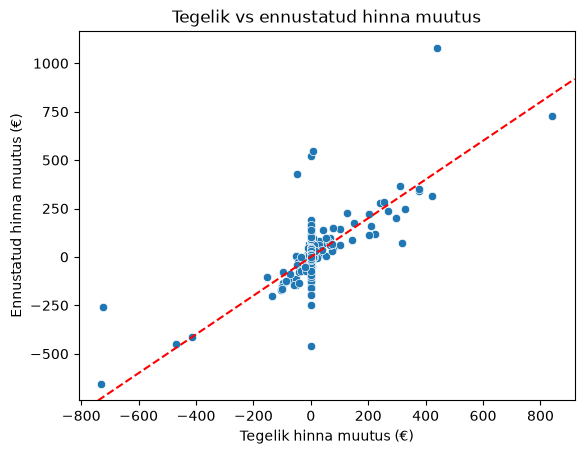

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=y_test,
    y=y_pred_test
)

plt.xlabel("Tegelik hinna muutus (€)")
plt.ylabel("Ennustatud hinna muutus (€)")
plt.title("Tegelik vs ennustatud hinna muutus")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.show()

# Lineaarregressiooni mudeli järeldis: ekstreemsed punktid raskendavad mudelil võrrelda. 
Katsetame andmed koondada log-transformeeritud kujul

## Näide (1)Mudel LF)

## hinna muutus eurodes actual distantsi võrdluses

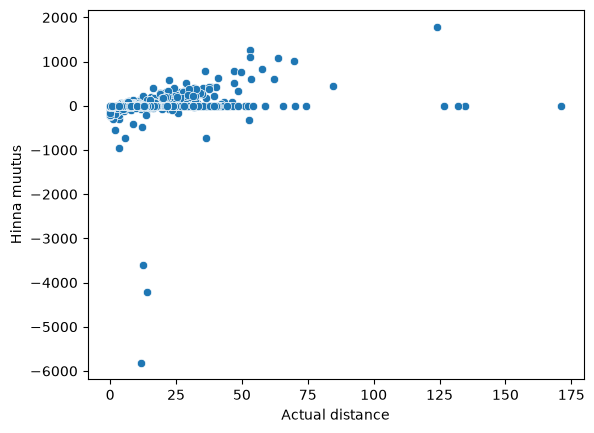

In [39]:
sns.scatterplot(
    data=mudel_andmed,
    x="distance_km",
    y="hinna_muutus_eur",
)

plt.xlabel("Actual distance")
plt.ylabel("Hinna muutus")
plt.show()

## hinna_muutus eurodes sõidu actual kestvuses võrdluses päeva perioodiga

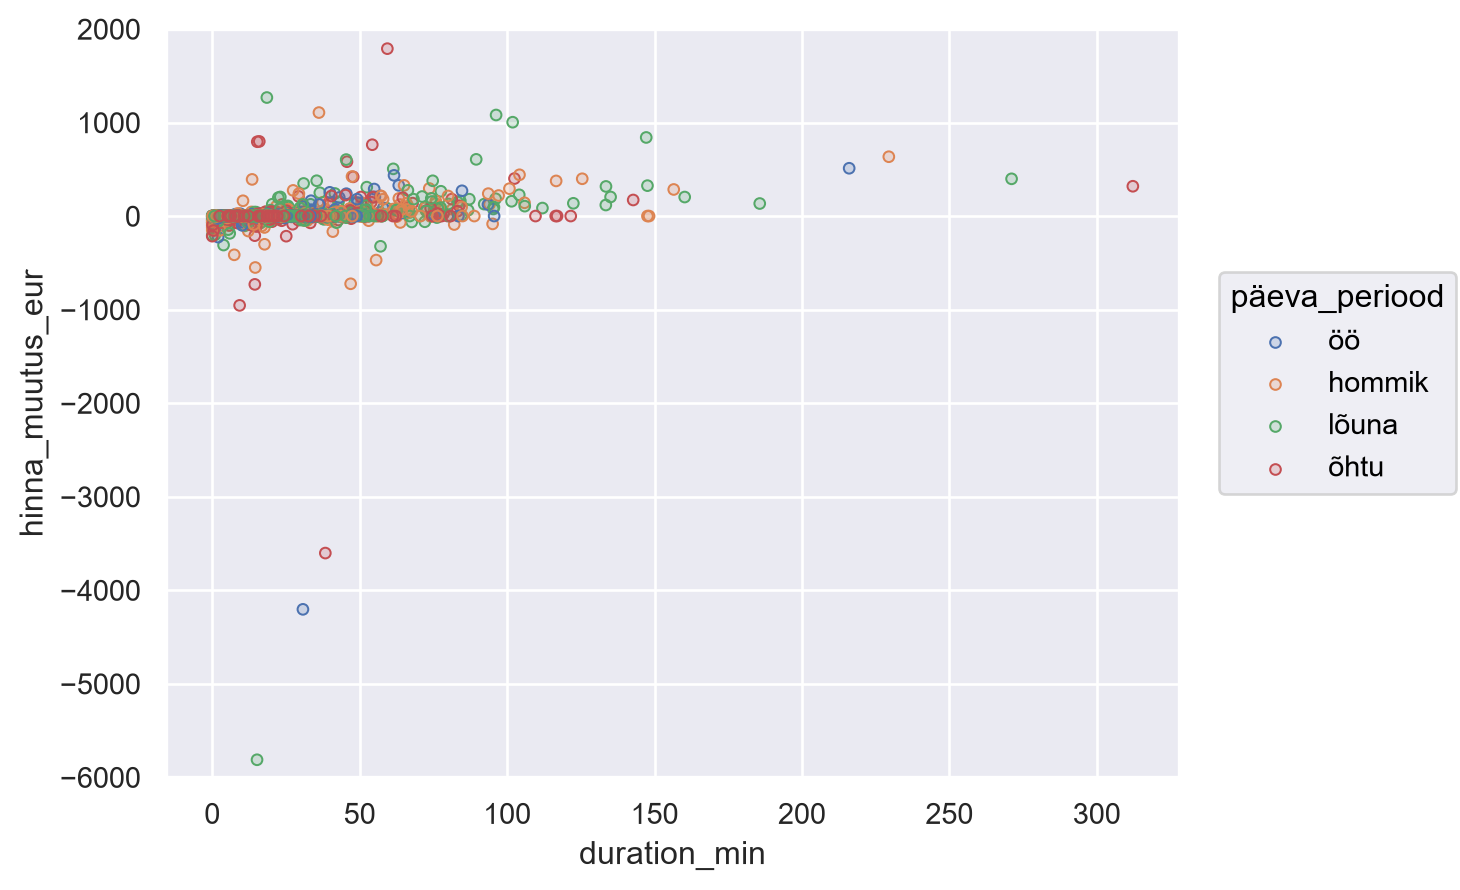

In [40]:
import seaborn.objects as so

(
       so.Plot(
        order_andmed,
        x="duration_min",
         y="hinna_muutus_eur",
        color="päeva_periood"
)
       .add(so.Dots(), so.Jitter())
    .limit(y=(-6000, 2000))
    
)

## Hinna muutus eurodes vs GPS

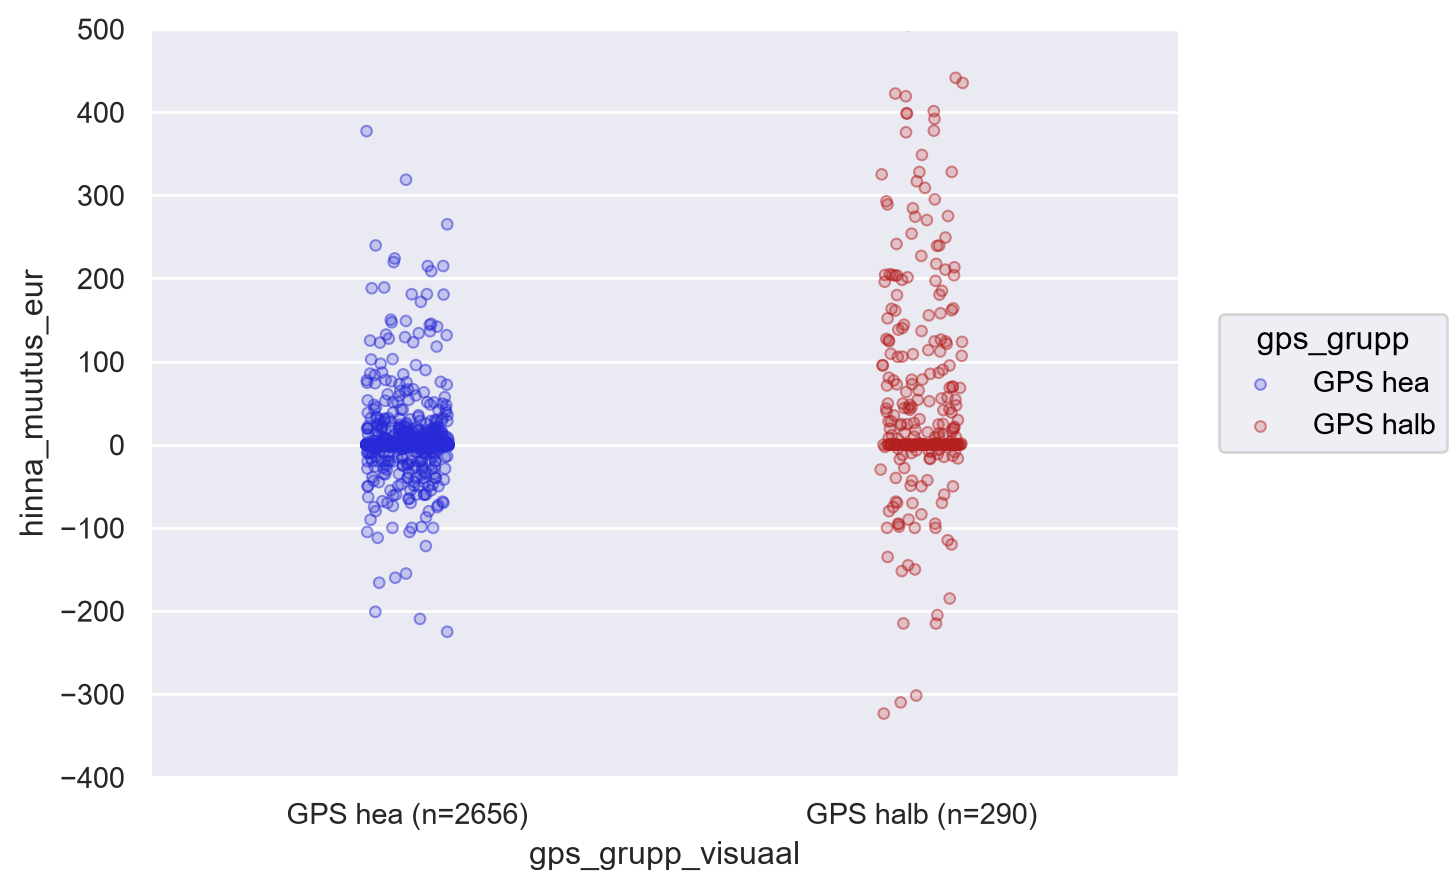

In [41]:
(
    so.Plot(
        mudel_andmed,
        x="gps_grupp_visuaal",
        y="hinna_muutus_eur",
        color="gps_grupp"
    )
    .add(so.Dots(alpha=0.5), so.Jitter())
    .scale(color=["#272ad6", "#b41f1f"])
    .limit(x=(-0.5, 1.5), y=(-400, 500))
)

## Hinna muutus eurodes vs EU

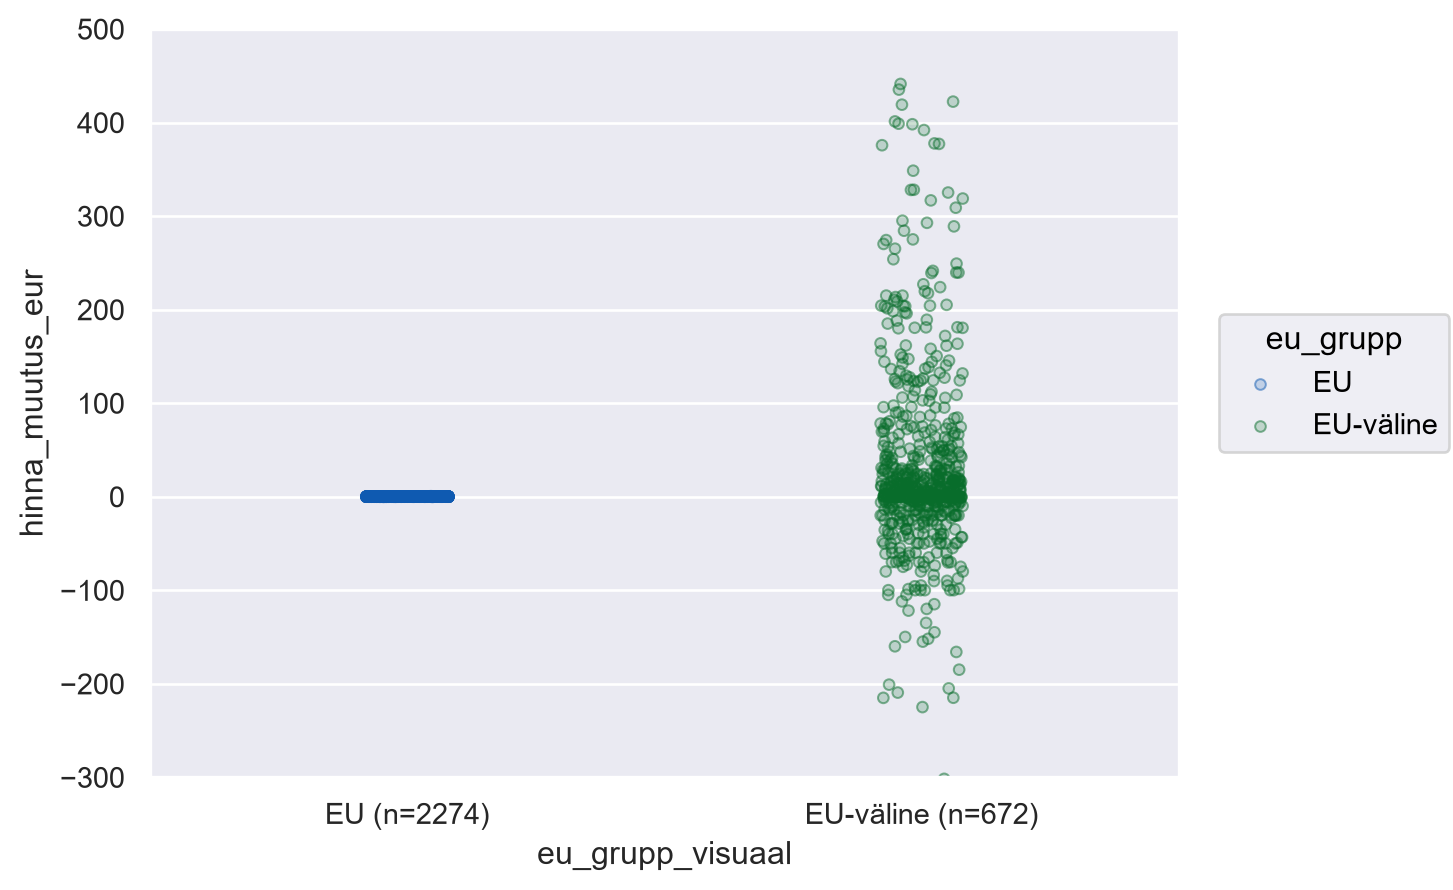

In [42]:
(
    so.Plot(
        mudel_andmed,
        x="eu_grupp_visuaal",
        y="hinna_muutus_eur",
        color="eu_grupp"
    )
    .add(so.Dots(alpha=0.5), so.Jitter())
    .scale(color=["#0f5ab1", "#086d2b"])
    .limit(y=(-300, 500))
)

### EU-välises grupis on tegeliku ja prognoositud sõiduaja erinevus suurem ning samal ajal on ka lõpliku ja ettemääratud hinna erinevus suurem.

In [43]:
mudel_andmed.groupby("eu_grupp")[
    ["predicted_duration_min", "duration_min",
     "predicted_distance_km", "distance_km"]
].median()

,predicted_duration_min,duration_min,predicted_distance_km,distance_km
eu_grupp,,,,
EU,12.400000,13.416667,5.8070,6.2215
EU-väline,20.991667,24.850000,8.1555,7.9900


### EU-välise grupi suurem hinnamuutus langeb kokku eelkõige suurema ajalise erinevusega, mitte suurema distantsi erinevusega.

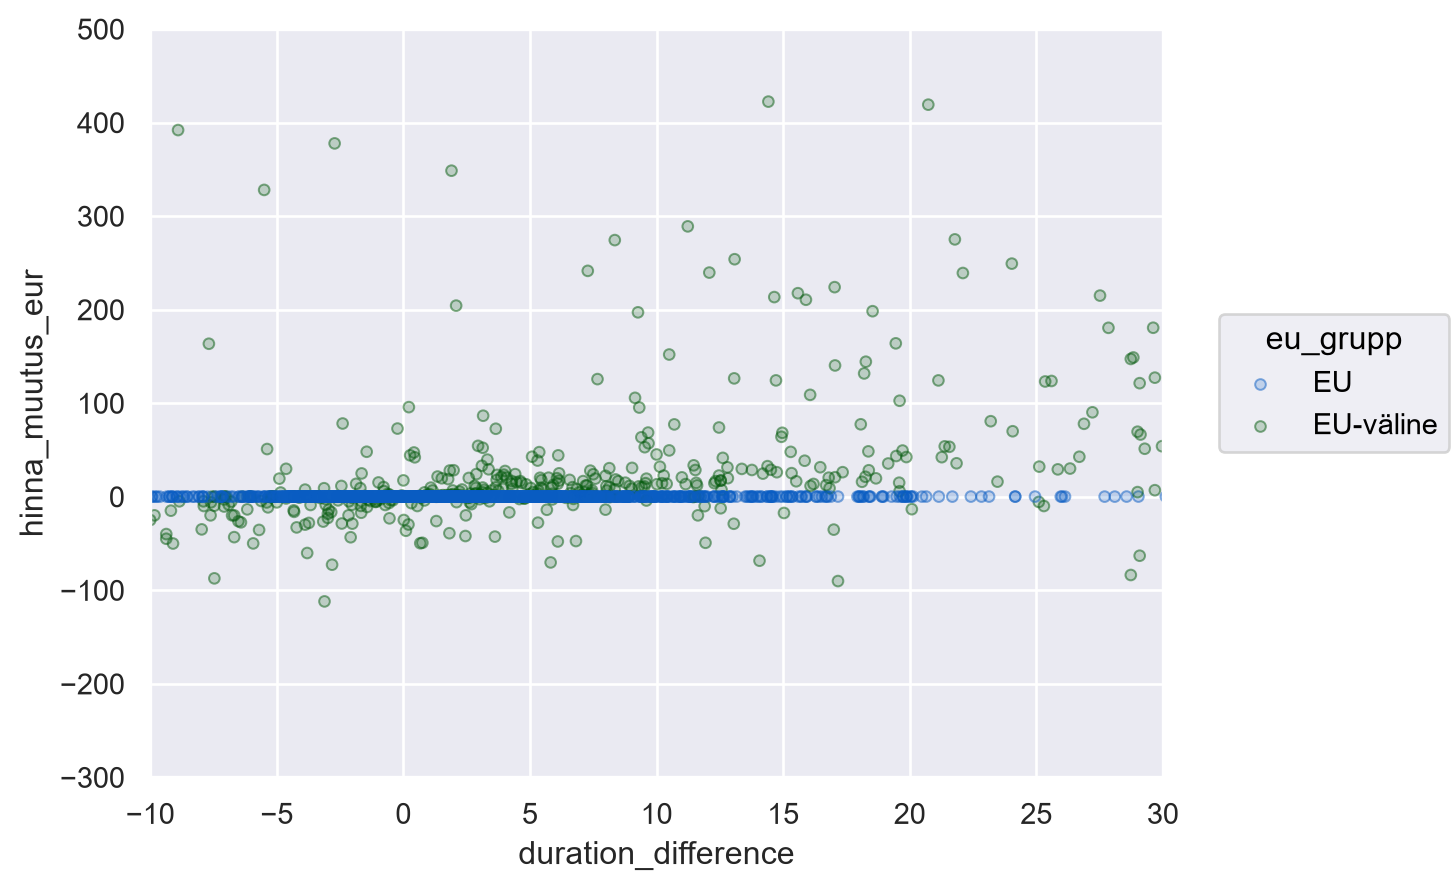

In [44]:
(
    so.Plot(
        mudel_andmed,
        x="duration_difference",
        y="hinna_muutus_eur",
        color="eu_grupp"
    )
    .add(so.Dots(alpha=0.5))
    .scale(color=["#0a5dc3", "#055b0e"])
    .limit(x=(-10, 30), y=(-300, 500))
)

##

EU

→ prognoositud aeg ~12,4 min
→ tegelik aeg ~13,4 min
→ mediaan duration_difference ~0,56 min
→ mediaan hinnamuutus ~0 €

EU-väline

→ prognoositud aeg ~21,0 min
→ tegelik aeg ~24,9 min
→ mediaan duration_difference ~4,04 min
→ mediaan hinnamuutus ~6,49 €
→ duration_difference ja hinnamuutuse korrelatsioon 0,66, tavapäraste väärtuste puhul 0,49

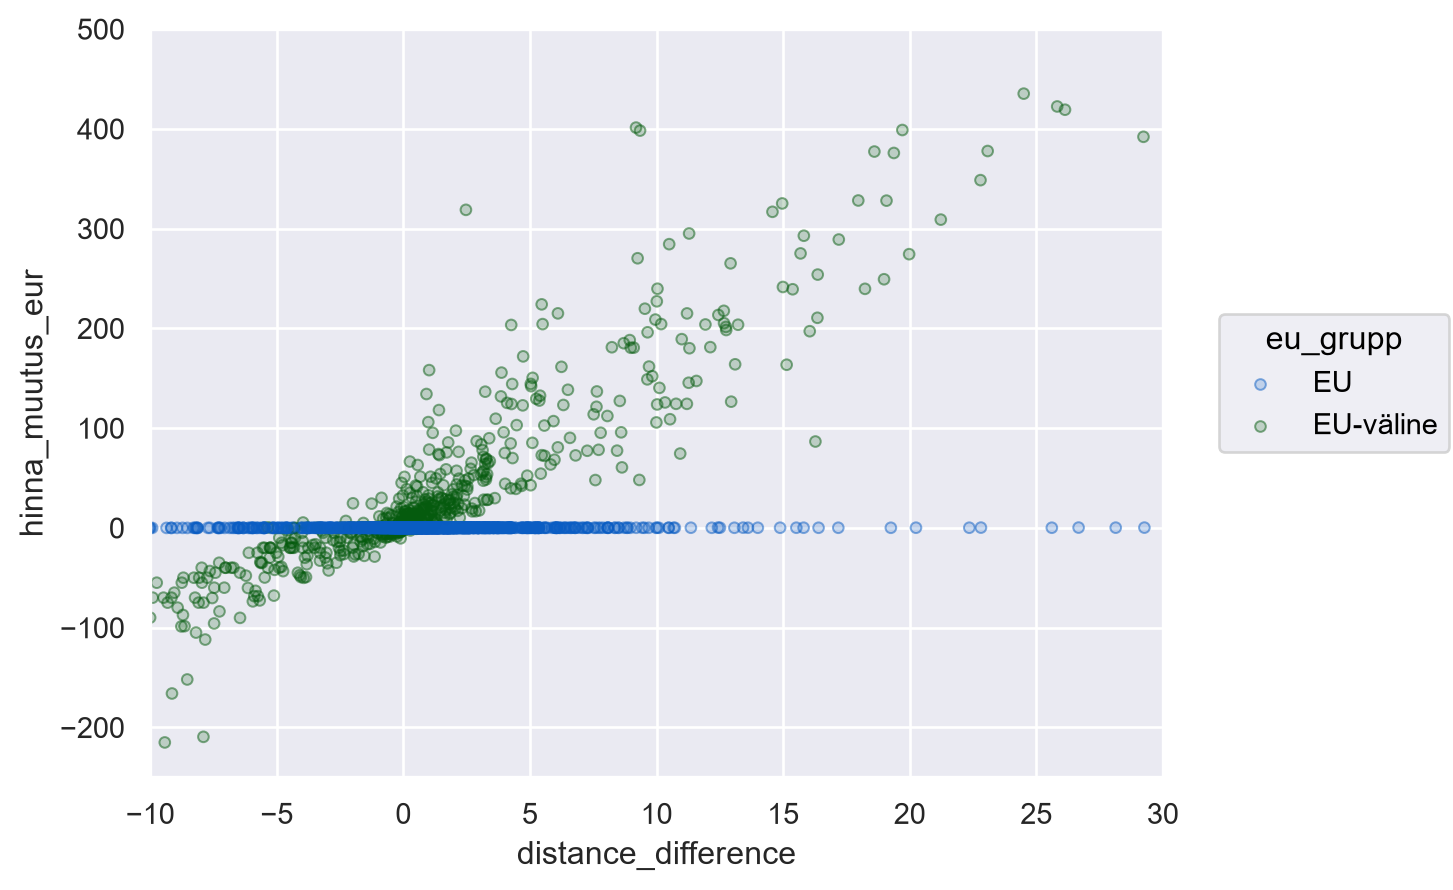

In [45]:
(
    so.Plot(
        mudel_andmed,
        x="distance_difference",
        y="hinna_muutus_eur",
        color="eu_grupp"
    )
    .add(so.Dots(alpha=0.5))
    .scale(color=["#0a5dc3", "#055b0e"])
    .limit(x=(-10, 30), y=(-250, 500))
)

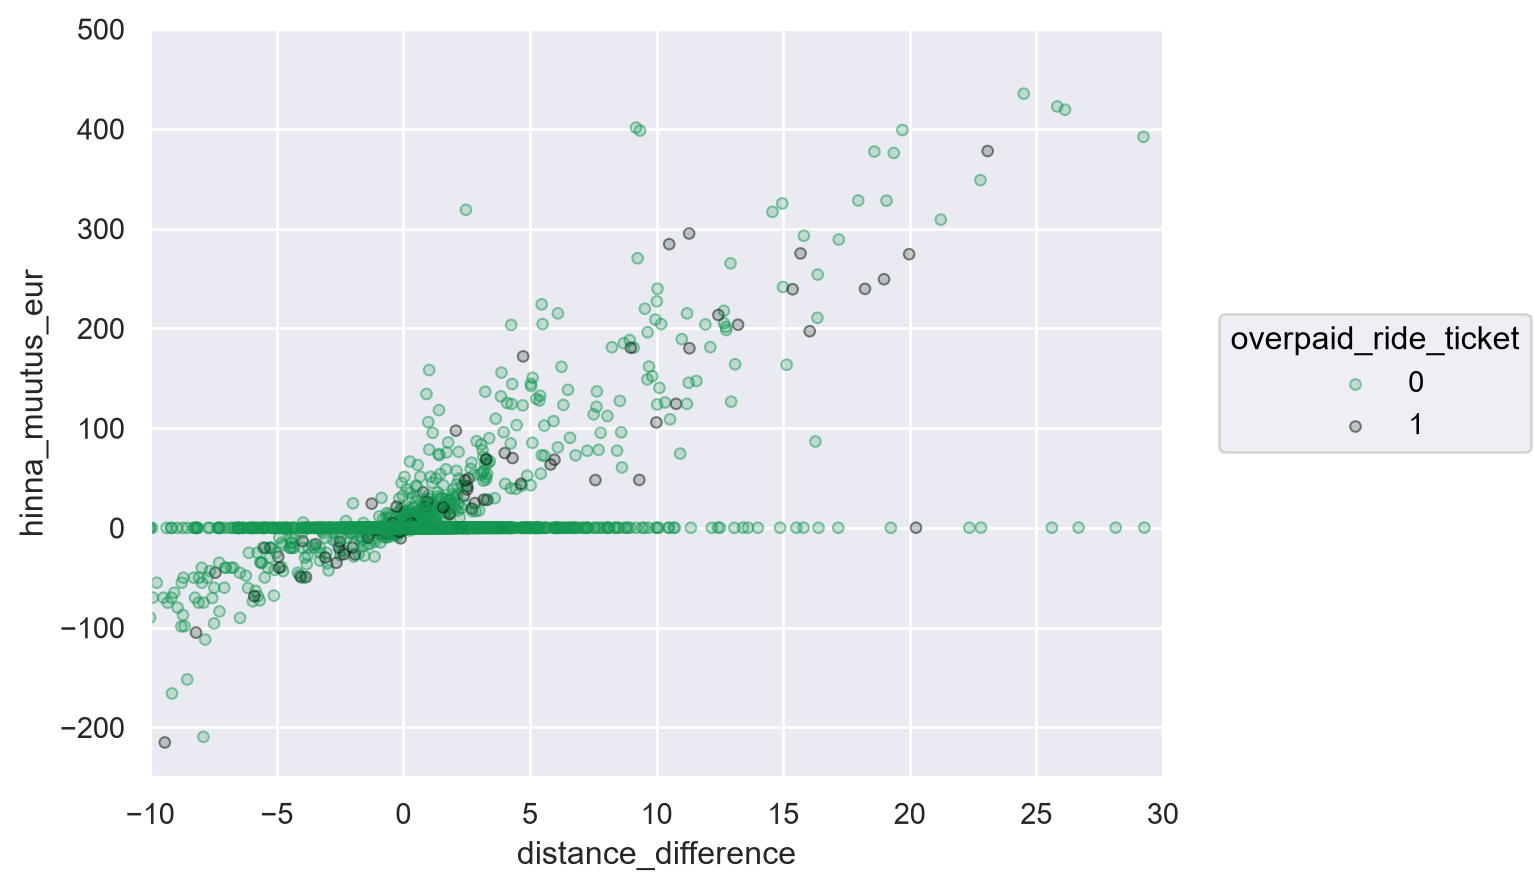

In [46]:
(
    so.Plot(
        mudel_andmed,
        x="distance_difference",
        y="hinna_muutus_eur",
        color="overpaid_ride_ticket"
    )
    .add(so.Dots(alpha=0.5))
    .scale(color=["#139751", "#021404"])
    .limit(x=(-10, 30), y=(-250, 500))
)

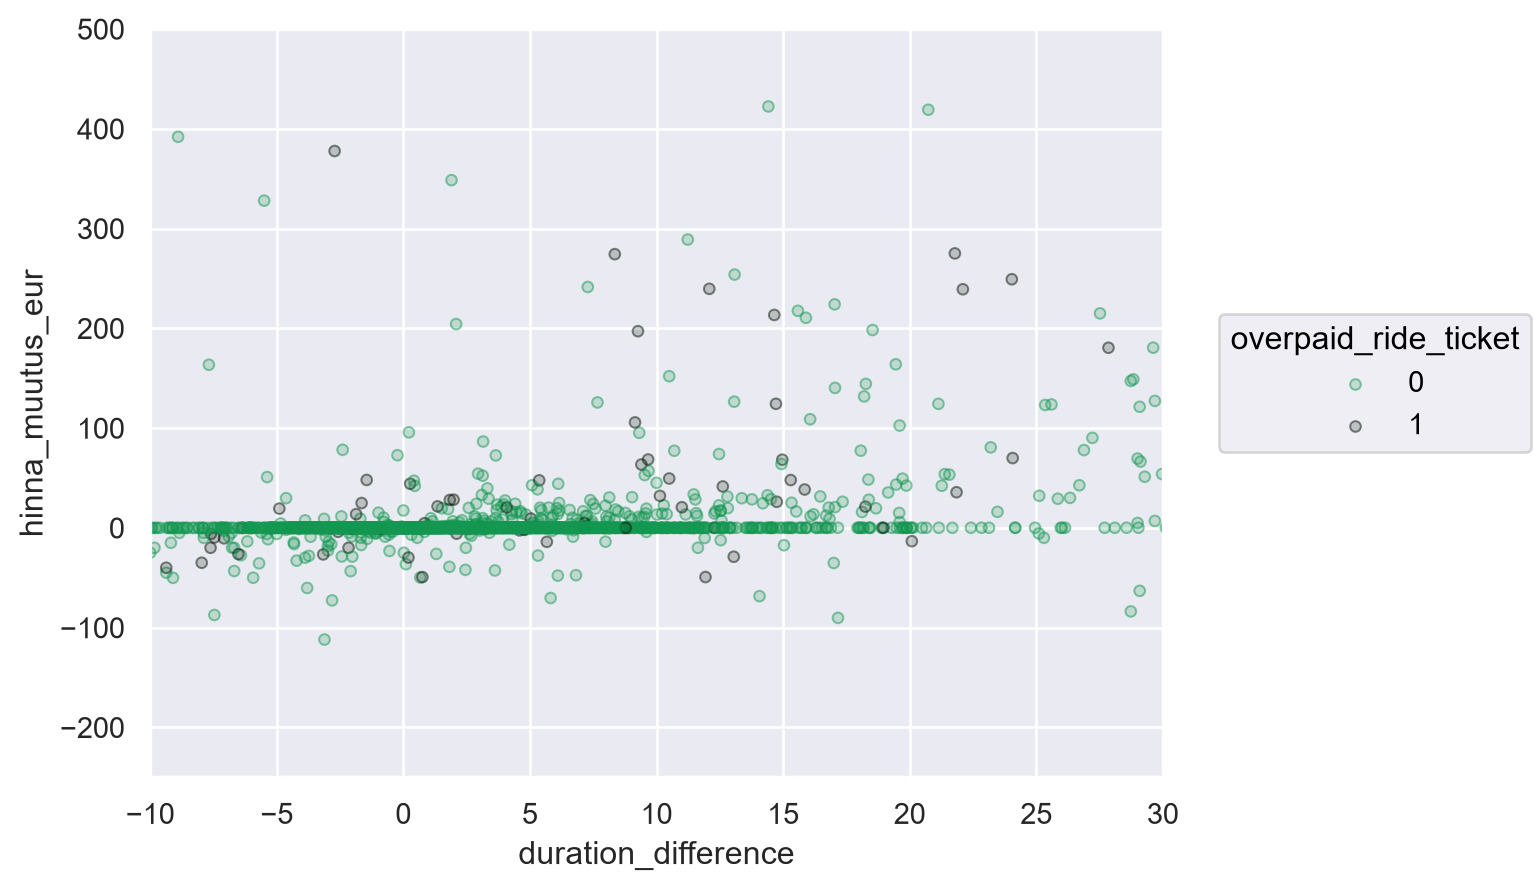

In [47]:
(
    so.Plot(
        mudel_andmed,
        x="duration_difference",
        y="hinna_muutus_eur",
        color="overpaid_ride_ticket"
    )
    .add(so.Dots(alpha=0.5))
    .scale(color=["#139751", "#021404"])
    .limit(x=(-10, 30), y=(-250, 500))
)

# 2)Mudel RandomForestClassifier

## Mudeli veergude loomine

In [48]:
features_rf = [
    "gps_confidence",
    "eu_indicator",
    "duration_difference",
    "distance_difference",
    "predicted_duration_min",
    "predicted_distance_km",
    "duration_min",
    "distance_km",
    "prediction_price_type",
    "dest_change_number",
    "fraud_score",
    "device_name",
    "päeva_periood",
    "weekday",
    "hour"
]

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=100,
    class_weight="balanced"
)

## Mudeli veergude kontroll

In [50]:
order_andmed[features_rf].isna().sum().sort_values(ascending=False)

duration_difference       19
predicted_duration_min    19
distance_difference       19
predicted_distance_km     19
prediction_price_type     19
eu_indicator               0
gps_confidence             0
duration_min               0
distance_km                0
dest_change_number         0
fraud_score                0
device_name                0
päeva_periood              0
weekday                    0
hour                       0
dtype: int64

## RF features 19 sõidu kõrvaldamine (0,46%)  4166 sõitude hulgast (NaNi ei saa mudelisse võtta)

In [51]:
rf_andmed = order_andmed.dropna(
    subset=features_rf
).copy()

## X ja Y telje loomine RF_andetel

In [52]:
X_rf = rf_andmed[features_rf]
y_rf = rf_andmed["overpaid_ride_ticket"]

## Train ja Test split

In [53]:
from sklearn.model_selection import train_test_split

x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=100,
    stratify=y_rf
)

## Splittimise kontroll

In [54]:
print(y_train_rf.value_counts())
print(y_test_rf.value_counts())

overpaid_ride_ticket
0    3070
1     247
Name: count, dtype: int64
overpaid_ride_ticket
0    768
1     62
Name: count, dtype: int64


## Pipeline

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_rf = [
    "prediction_price_type",
    "device_name",
    "päeva_periood",
    "weekday"
]

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_rf
        )
    ],
    remainder="passthrough"
)

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=100,
        class_weight="balanced"
    ))
])

## Mudeli fittimine x_train_rf ja y_train_rf

In [57]:
rf_model.fit(x_train_rf, y_train_rf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['gps_confidence','eu_indicator','duration_difference',...,'päeva_periood', 'weekday','hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthr

## Kontroll

In [58]:
y_pred_rf = rf_model.predict(x_test_rf)

from sklearn.metrics import classification_report

print(classification_report(y_test_rf, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       768
           1       0.44      0.32      0.37        62

    accuracy                           0.92       830
   macro avg       0.70      0.65      0.67       830
weighted avg       0.91      0.92      0.91       830



## Klass 0 / No Overcharge ja klass 1 / Overcharge

* Precision 0,44 → kui mudel ütleb "OVERCHARGE", siis umbes 44% neist on tegelikult overcharge.
* Recall 0,32 → mudel leidis üles ainult umbes 32% tegelikest overcharge-sõitudest.
* Testis oli 62 tegelikku overcharge-sõitu, seega leidis mudel neist umbes 20 üles.

## Confusion Matrix

In [59]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_rf, y_pred_rf)

array([[743,  25],
       [ 42,  20]])

In [60]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importance = rf_model.named_steps["classifier"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
487,remainder__eu_indicator,0.124213
489,remainder__distance_difference,0.067238
488,remainder__duration_difference,0.064463
492,remainder__duration_min,0.064223
493,remainder__distance_km,0.060860
490,remainder__predicted_duration_min,0.058501
486,remainder__gps_confidence,0.055231
495,remainder__fraud_score,0.053827
491,remainder__predicted_distance_km,0.049811
0,cat__prediction_price_type_prediction,0.047618


## Klientide kaebuste osakaal võrdluses hinnastava kategooriate ning päeva perioodi näitel

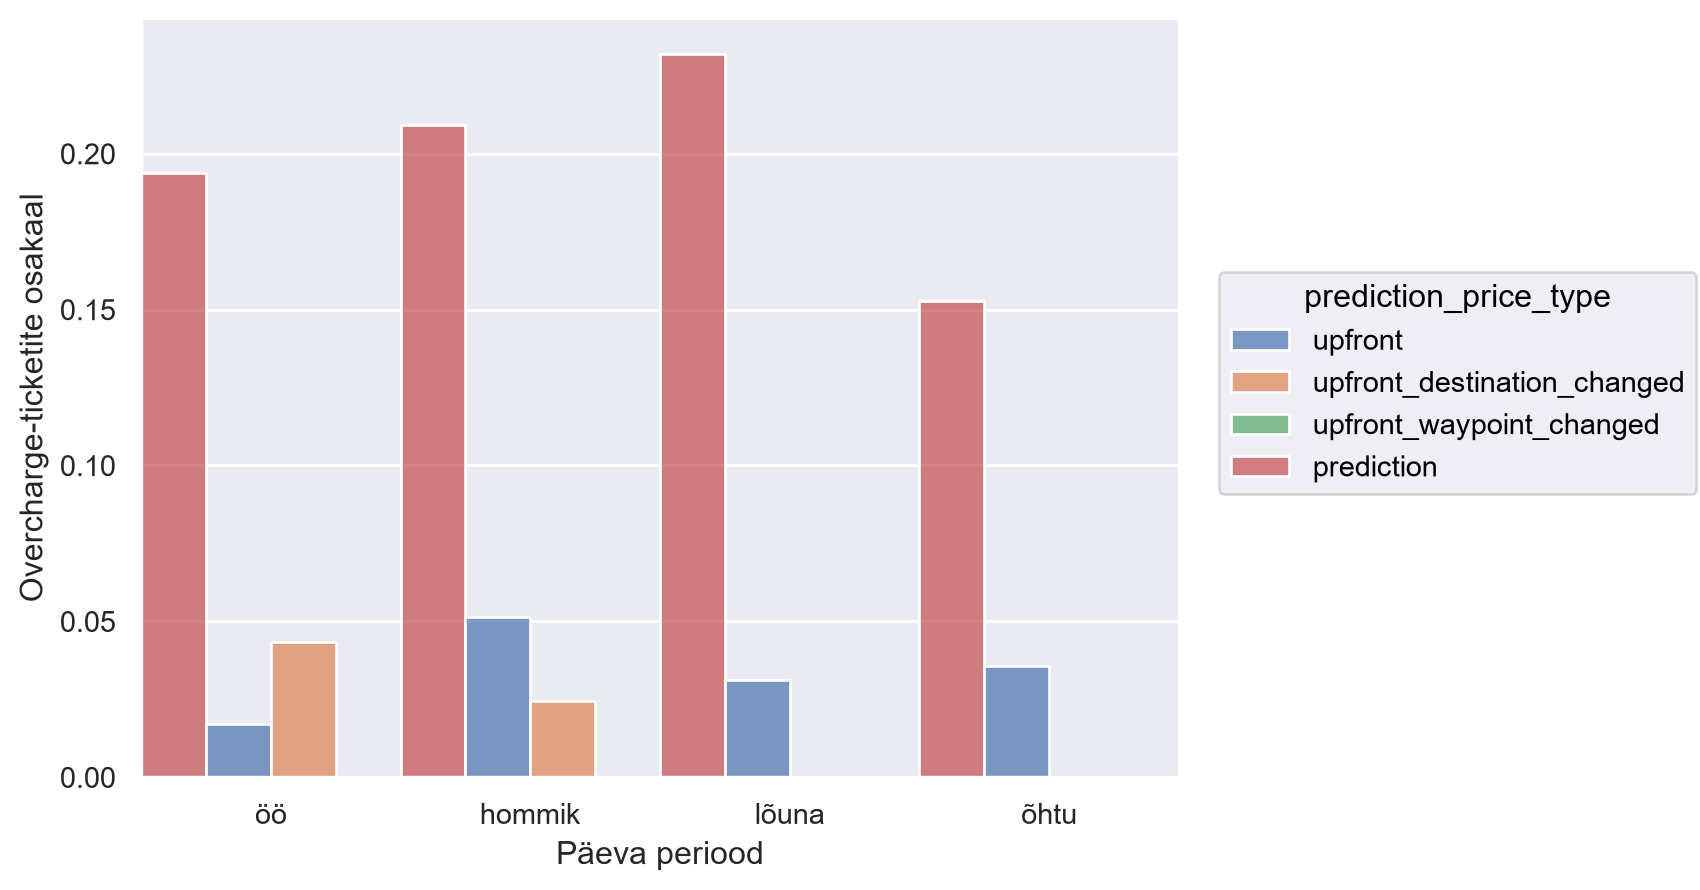

In [61]:
rf_andmed["prediction_price_type"] = pd.Categorical(
    rf_andmed["prediction_price_type"],
    categories=[
        "prediction",
        "upfront",
        "upfront_destination_changed",
        "upfront_waypoint_changed"
    ],
    ordered=True
)

(
    so.Plot(
        rf_andmed,
        x="päeva_periood",
        y="overpaid_ride_ticket",
        color="prediction_price_type"
    )
    .add(
        so.Bars(),
        so.Agg("mean"),
        so.Dodge()
    )
    .label(
        x="Päeva periood",
        y="Overcharge-ticketite osakaal"
    )
)

In [62]:
periood_osakaal = (
    rf_andmed
    .groupby("päeva_periood", observed=True)["overpaid_ride_ticket"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

periood_osakaal["overcharge_pct"] = (
    periood_osakaal["mean"] * 100
)

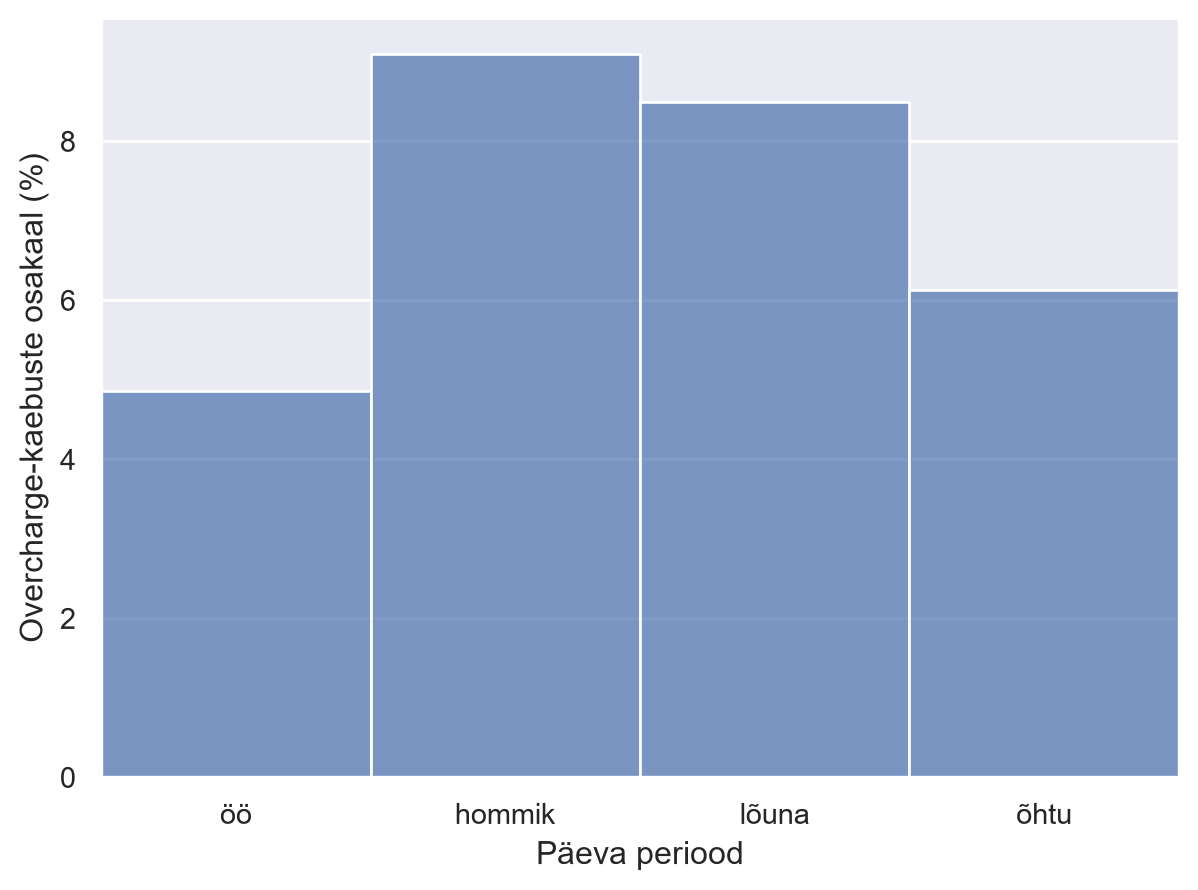

In [94]:
(
    so.Plot(
        periood_osakaal,
        x="päeva_periood",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Päeva periood",
        y="Overcharge-kaebuste osakaal (%)"
    )
)

## Kõikide sõitude arv vs päeva perioodiga (osakaaluna võrdluses)

In [100]:
periood_kogus = (
    rf_andmed["päeva_periood"]
    .value_counts()
    .sort_index()
    .rename("sõite")
    .reset_index()
)

periood_kogus["osakaal_pct"] = (
    periood_kogus["sõite"] / len(rf_andmed) * 100
)

periood_kogus

,päeva_periood,sõite,osakaal_pct
0,öö,762,18.374729
1,hommik,1100,26.525199
2,lõuna,1354,32.650109
3,õhtu,931,22.449964


## Prediction grupi sõitude jaotus päeva perioodi kaupa osakaaluna võrdluses

In [99]:
prediction_periood = (
    prediction_andmed["päeva_periood"]
    .value_counts()
    .sort_index()
    .rename("sõite")
    .reset_index()
)

prediction_periood["osakaal_pct"] = (
    prediction_periood["sõite"] /
    len(prediction_andmed) * 100
)

prediction_periood

,päeva_periood,sõite,osakaal_pct
0,öö,129,12.925852
1,hommik,282,28.256513
2,lõuna,371,37.174349
3,õhtu,216,21.643287


# Järeldus:                                                                                                                        

* Prediction-tüüpi sõitude suurem osakaal hommikul ja lõuna ajal võib olla üks tegur, mis aitab kaasa nende perioodide kõrgemale overcharge-kaebuste määrale.

# Kaebuste osakaal vs päeva periood

In [101]:
prediction_periood_osakaal = (
    prediction_andmed
    .groupby("päeva_periood", observed=True)["overpaid_ride_ticket"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

prediction_periood_osakaal["overcharge_pct"] = (
    prediction_periood_osakaal["mean"] * 100
)

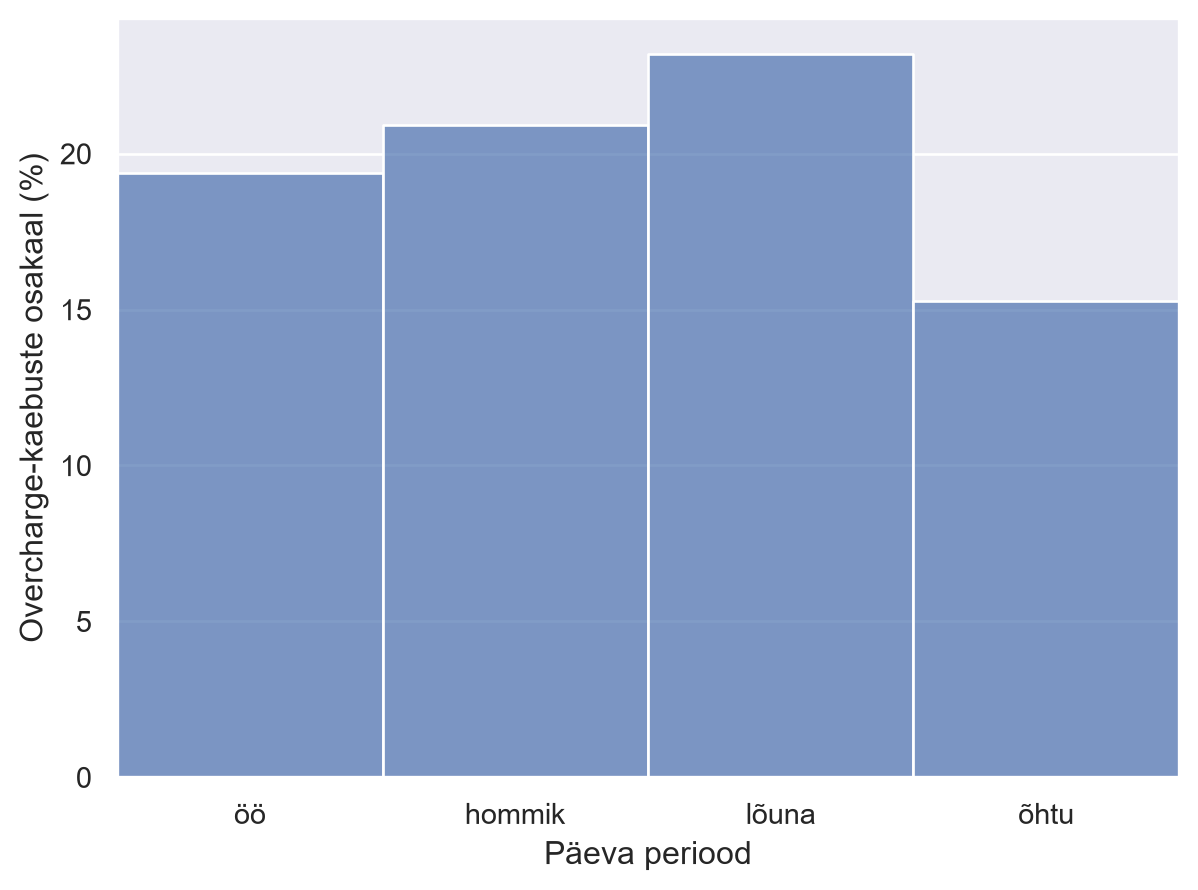

In [102]:
(
    so.Plot(
        prediction_periood_osakaal,
        x="päeva_periood",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Päeva periood",
        y="Overcharge-kaebuste osakaal (%)"
    )
)

# Klientide kaebusega ticketite osakaalu võrdlus sõidu actual aja - ennustatud aja võrdluses

In [63]:
rf_andmed["duration_diff_grupp"] = pd.cut(
    rf_andmed["duration_difference"],
    bins=[-10, -5, 0, 5, 10, 20, 30, 60, np.inf]
)

In [64]:
osakaal = (
    rf_andmed
    .groupby("duration_diff_grupp", observed=True)
    ["overpaid_ride_ticket"]
    .mean()
    .reset_index()
)

In [65]:
osakaal["overcharge_pct"] = (
    osakaal["overpaid_ride_ticket"] * 100
)

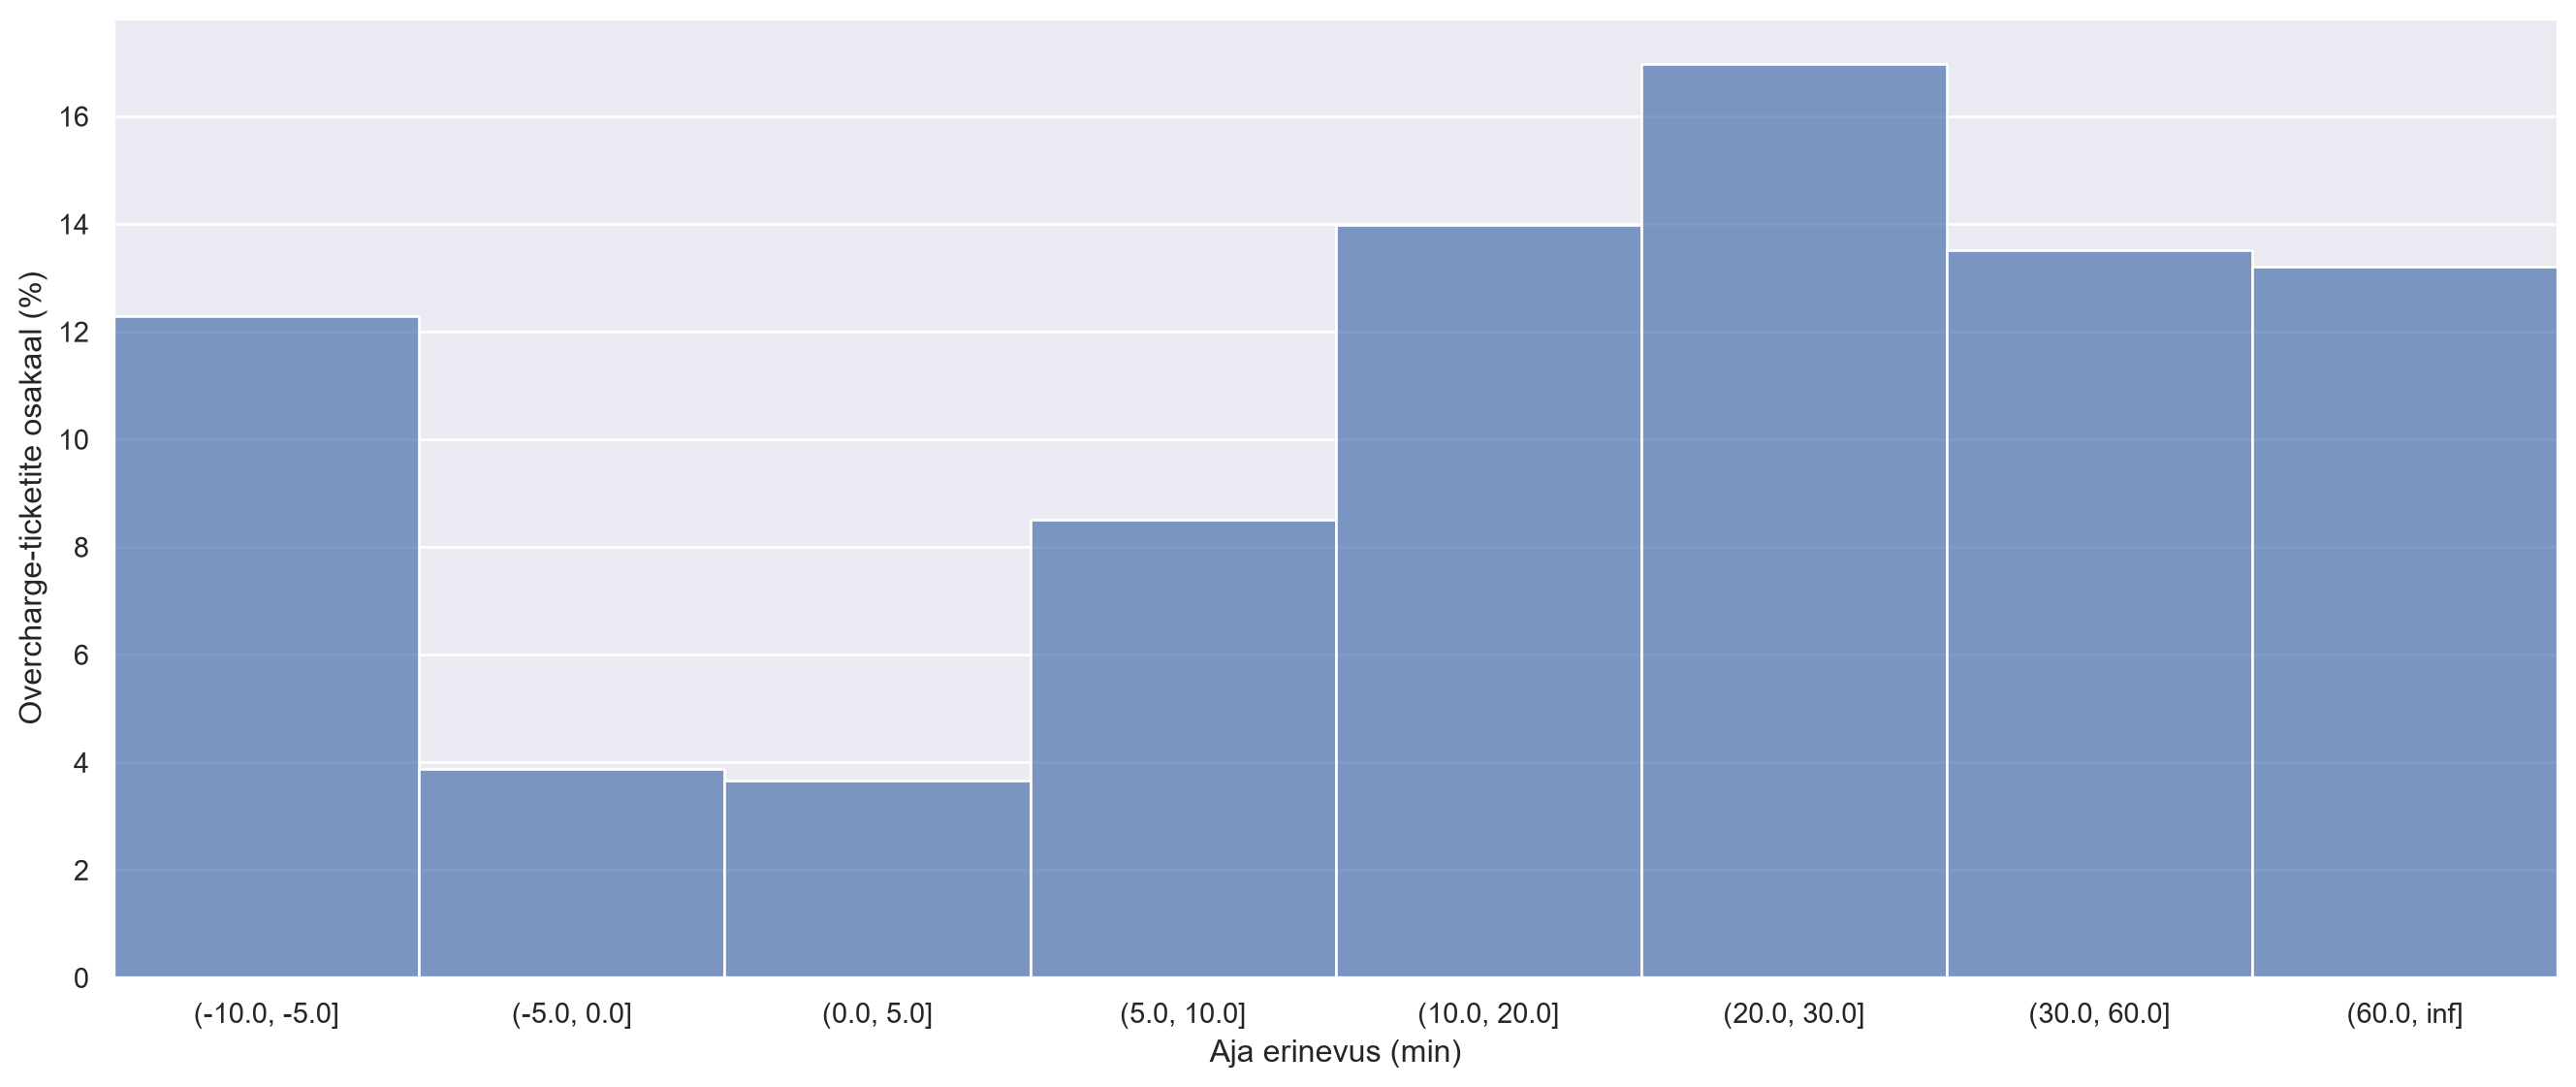

In [66]:
(
    so.Plot(
        osakaal,
        x="duration_diff_grupp",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Aja erinevus (min)",
        y="Overcharge-ticketite osakaal (%)"
    )
    .theme({
        "figure.figsize": (14, 6)
    })
)

## suurim overcharge-ticketite osakaal on sõitudel, kus tegelik sõiduaeg on prognoositust üle 20 kuni 30 minuti pikem.

In [67]:
rf_andmed["duration_min_grupp"] = pd.cut(
    rf_andmed["duration_min"],
    bins=[-10, -5, 0, 5, 10, 20, 30, 60, np.inf]
)

In [68]:
osakaal1 = (
    rf_andmed
    .groupby("duration_min_grupp", observed=True)
    ["overpaid_ride_ticket"]
    .mean()
    .reset_index()
)

In [69]:
osakaal1["overcharge_pct"] = (
    osakaal1["overpaid_ride_ticket"] * 100
)

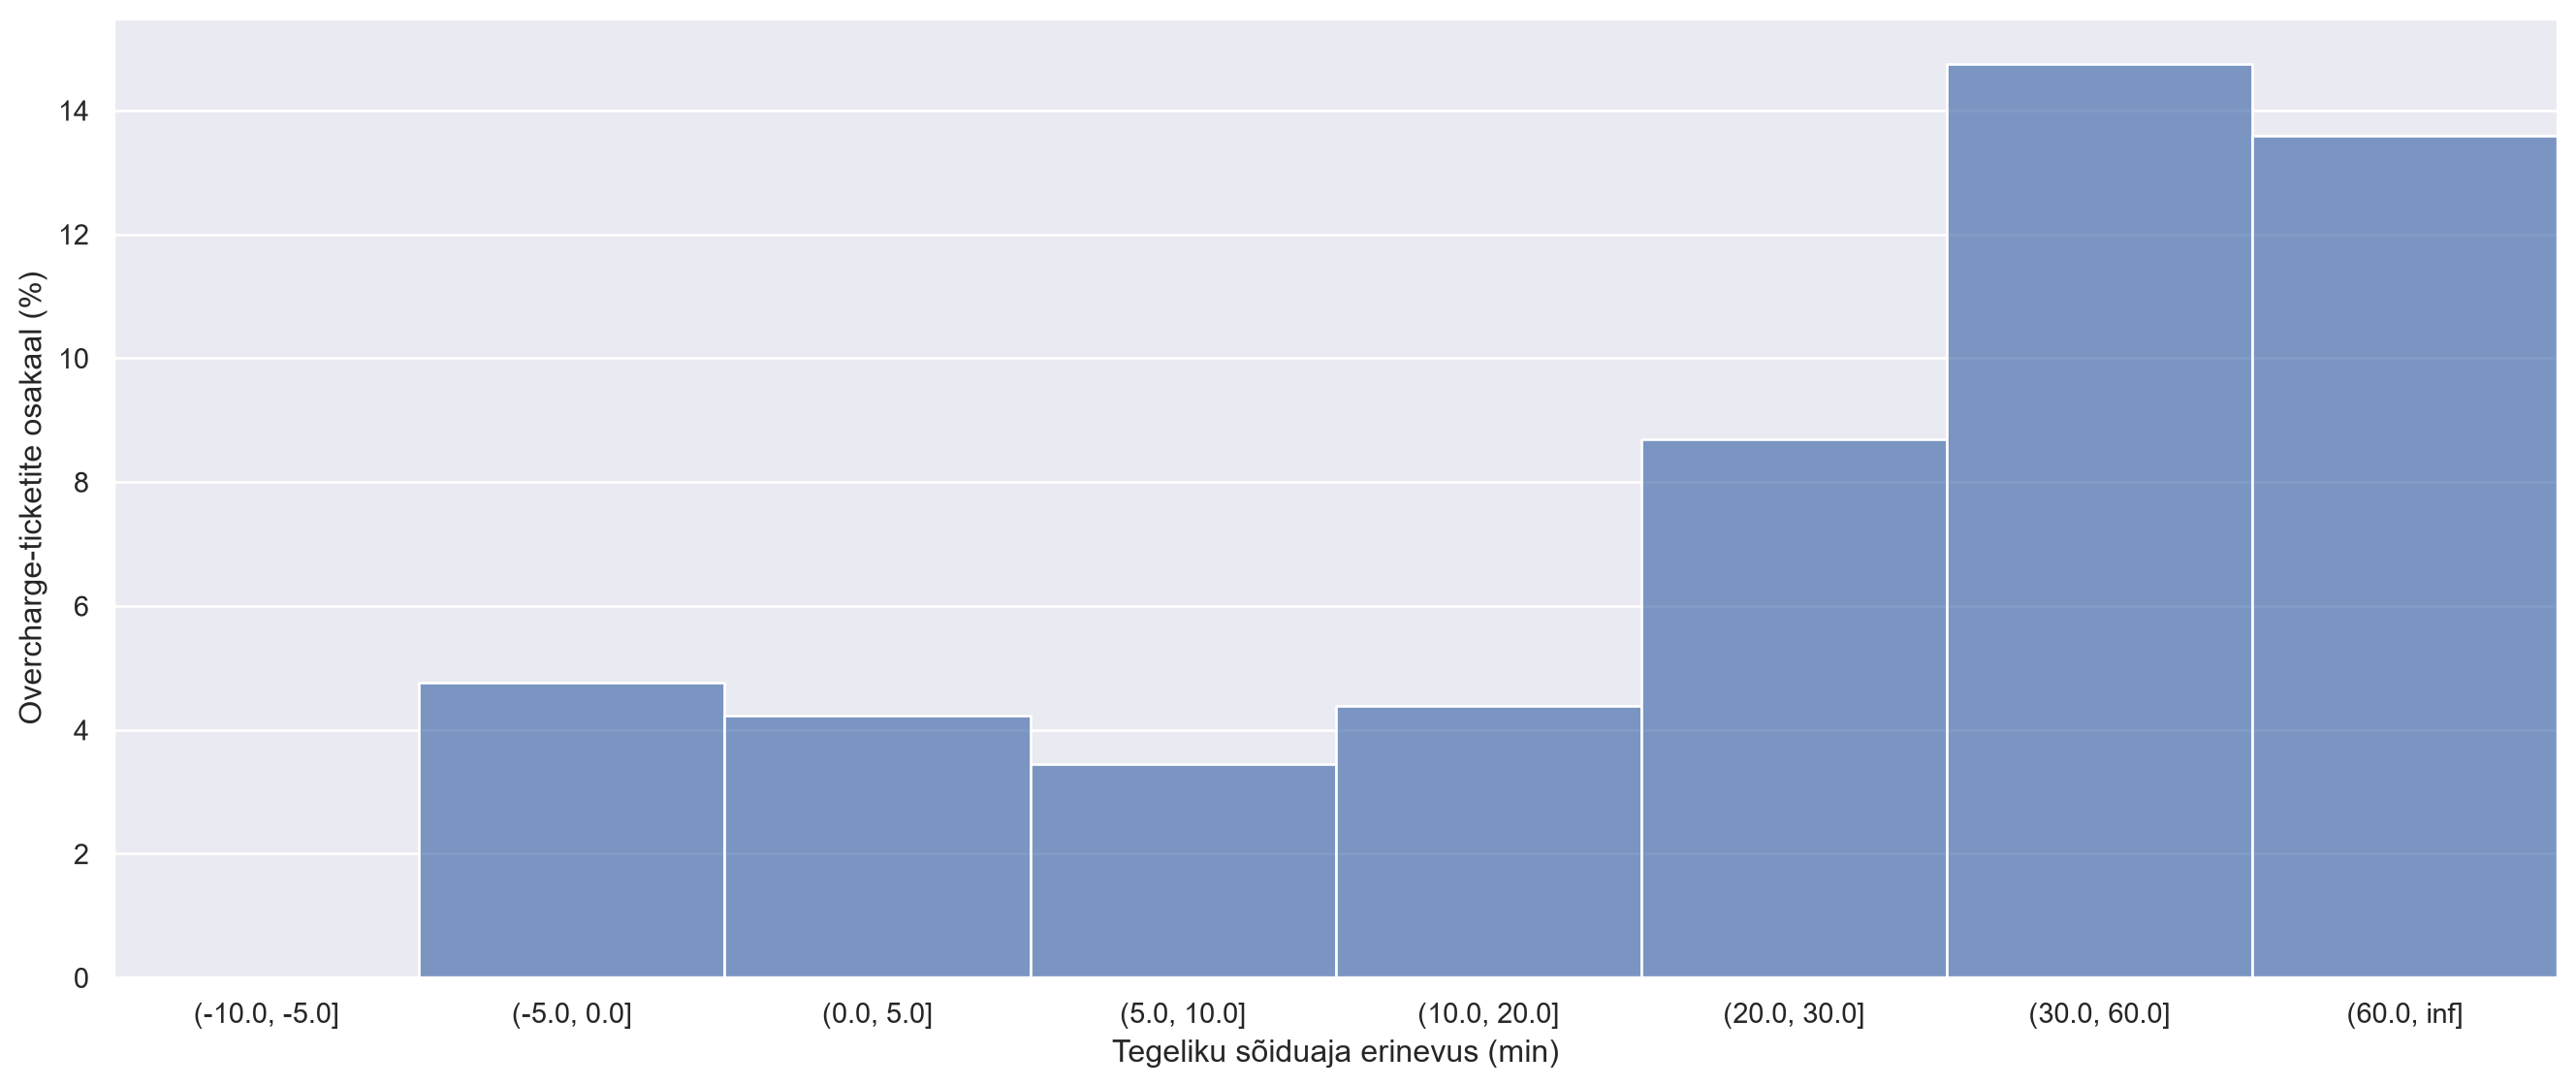

In [70]:
(
    so.Plot(
        osakaal1,
        x="duration_min_grupp",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Tegeliku sõiduaja erinevus (min)",
        y="Overcharge-ticketite osakaal (%)"
    )
    .theme({
        "figure.figsize": (14, 6)
    })
)

# „Miks on prediction kategoorias overcharge-ticketite osakaal nii palju suurem?”

* 998 sõitu ja 203 overcharge-sõitu. 
* 203 meie 309 order-taseme overcharge-sõidust tuleb sellest grupist ehk umbes 66%.

# 3)Mudeli loomine

## Ainult prediction/ennustatud sõidud

In [71]:
prediction_andmed = rf_andmed[
    rf_andmed["prediction_price_type"] == "prediction"
].copy()

In [72]:
prediction_andmed["overpaid_ride_ticket"].value_counts()

overpaid_ride_ticket
0    795
1    203
Name: count, dtype: int64

## Mudeli veergude loomine

In [73]:
features_prediction = [
    "gps_confidence",
    "eu_indicator",
    "duration_difference",
    "distance_difference",
    "predicted_duration",
    "predicted_distance",
    "duration",
    "distance",
    "dest_change_number",
    "fraud_score",
    "device_name",
    "päeva_periood",
    "weekday",
    "hour"
]

## X ja Y telje loomine

In [74]:
X_prediction = prediction_andmed[features_prediction]
y_prediction = prediction_andmed["overpaid_ride_ticket"]

## Splittimine

In [75]:
x_train_pred, x_test_pred, y_train_pred, y_test_pred = train_test_split(
    X_prediction,
    y_prediction,
    test_size=0.2,
    random_state=100,
    stratify=y_prediction
)

## Preprocessor

In [76]:
categorical_prediction = [
    "device_name",
    "päeva_periood",
    "weekday"
]

preprocessor_prediction = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_prediction
        )
    ],
    remainder="passthrough"
)

## Pipeline

In [77]:
rf_prediction = Pipeline([
    ("preprocessor", preprocessor_prediction),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=100,
        class_weight="balanced"
    ))
])

## Fittimine

In [78]:
rf_prediction.fit(x_train_pred, y_train_pred)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['gps_confidence','eu_indicator','duration_difference',...,'päeva_periood', 'weekday','hour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthr

## Ennustus

In [79]:
y_pred_prediction = rf_prediction.predict(x_test_pred)

## Raport

In [80]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_pred,
    y_pred_prediction
))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       159
           1       0.39      0.27      0.32        41

    accuracy                           0.77       200
   macro avg       0.61      0.58      0.59       200
weighted avg       0.74      0.77      0.75       200



## JÄRELDUS:

Prediction-kategooria kõrge 20,3% overcharge-määr ei ole meie olemasolevate tunnuste põhjal lihtsalt väga hästi ennustatav.

In [81]:
feature_names_pred = rf_prediction.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_pred = rf_prediction.named_steps[
    "classifier"
].feature_importances_

feature_importance_pred = (
    pd.DataFrame({
        "feature": feature_names_pred,
        "importance": importance_pred
    })
    .sort_values("importance", ascending=False)
)

feature_importance_pred.head(20)

,feature,importance
220,remainder__distance_difference,0.108941
224,remainder__distance,0.106331
221,remainder__predicted_duration,0.081508
222,remainder__predicted_distance,0.079749
223,remainder__duration,0.078733
219,remainder__duration_difference,0.076474
217,remainder__gps_confidence,0.059834
227,remainder__hour,0.055091
213,cat__weekday_Sunday,0.013788
7,cat__device_name_HMD Global Nokia 2.2,0.011684


## Kui võtame EU-staatuse ära, sest kõik prediction-sõidud on siin juba eu_indicator = 0, siis distants muutub prediction-grupi sees kõige olulisemaks tunnuseks.

In [82]:
prediction_andmed["distance_grupp"] = pd.cut(
    prediction_andmed["distance_km"],
    bins=[0, 2, 5, 10, 15, 20, np.inf]
)

prediction_andmed.groupby(
    "distance_grupp",
    observed=True
)["overpaid_ride_ticket"].agg(["count", "sum", "mean"])

,count,sum,mean
distance_grupp,,,
"(0.0, 2.0]",139,11,0.079137
"(2.0, 5.0]",175,23,0.131429
"(5.0, 10.0]",297,57,0.191919
"(10.0, 15.0]",190,38,0.200000
"(15.0, 20.0]",77,24,0.311688
"(20.0, inf]",107,48,0.448598


# Ennustatava sõitude kaebuste osakaal vs tegeliku sõidudistantsiga

In [83]:
prediction_andmed["distance_grupp"] = pd.cut(
    prediction_andmed["distance_km"],
    bins=[0, 2, 5, 10, 15, 20, np.inf]
)

distance_osakaal = (
    prediction_andmed
    .groupby("distance_grupp", observed=True)["overpaid_ride_ticket"]
    .mean()
    .reset_index()
)

distance_osakaal["overcharge_pct"] = (
    distance_osakaal["overpaid_ride_ticket"] * 100
)

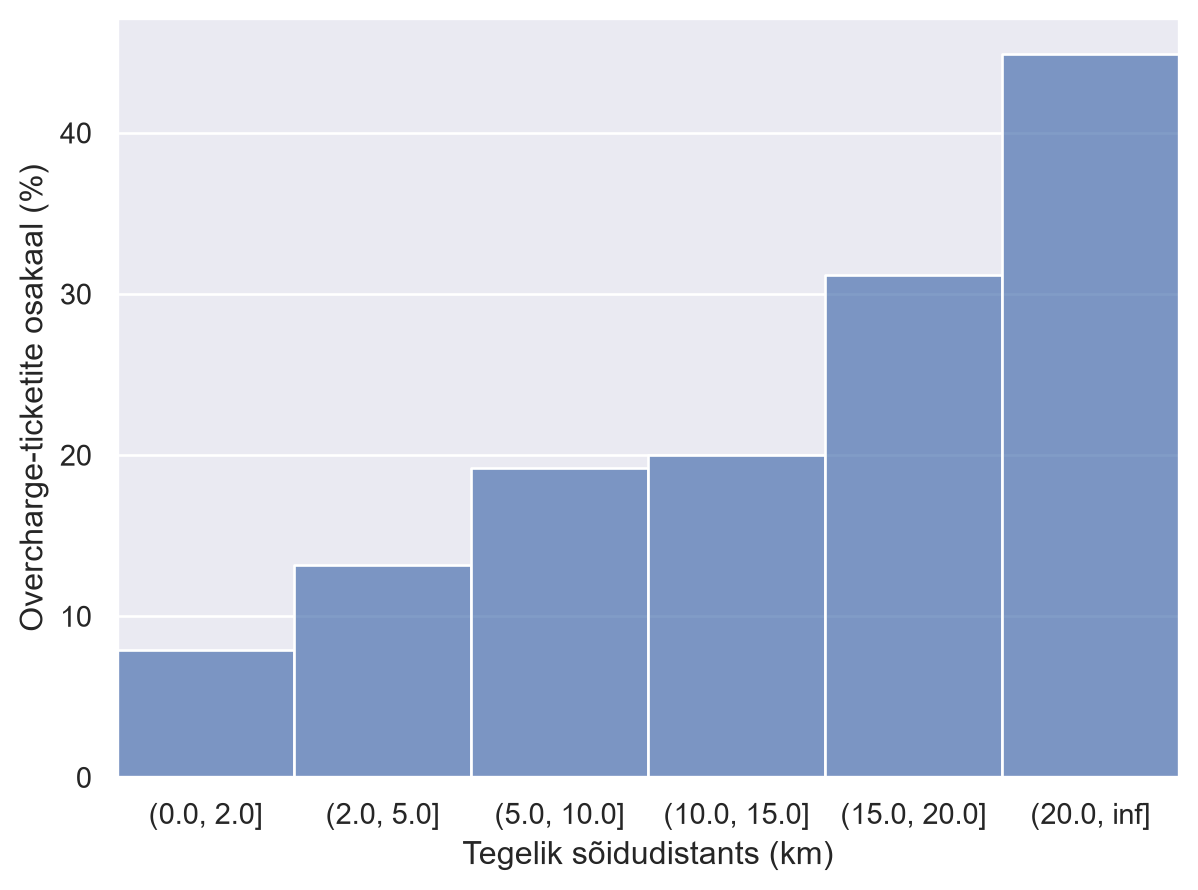

In [84]:
(
    so.Plot(
        distance_osakaal,
        x="distance_grupp",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Tegelik sõidudistants (km)",
        y="Overcharge-ticketite osakaal (%)"
    )
)

# Ennustatava sõitude kaebuste osakaal vs tegeliku sõiduajaga

In [85]:
prediction_andmed["duration_grupp"] = pd.cut(
    prediction_andmed["duration_min"],
    bins=[0, 5, 10, 15, 20, 30, 60, np.inf]
)

duration_osakaal = (
    prediction_andmed
    .groupby("duration_grupp", observed=True)["overpaid_ride_ticket"]
    .mean()
    .reset_index()
)

duration_osakaal["overcharge_pct"] = (
    duration_osakaal["overpaid_ride_ticket"] * 100
)

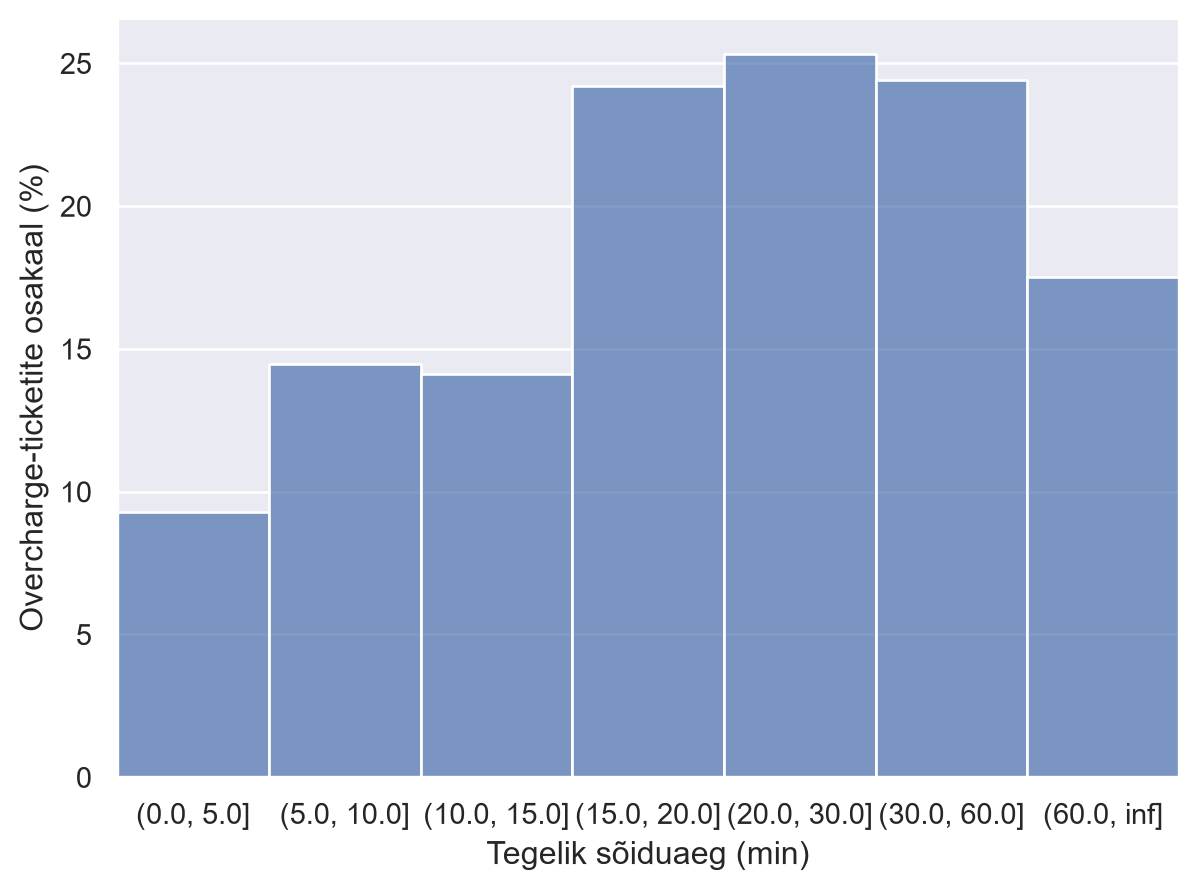

In [86]:
(
    so.Plot(
        duration_osakaal,
        x="duration_grupp",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Tegelik sõiduaeg (min)",
        y="Overcharge-ticketite osakaal (%)"
    )
)

# Ennustatava sõitude kaebuste osakaal vs seadme brändid

In [87]:
prediction_andmed["device_brand"] = (
    prediction_andmed["device_name"]
    .str.split()
    .str[0]
)

In [88]:
prediction_andmed["device_brand"] = (
    prediction_andmed["device_name"]
    .str.upper()
    .str.strip()
)

prediction_andmed["device_brand"] = np.select(
    [
        prediction_andmed["device_brand"].str.startswith("TECNO"),
        prediction_andmed["device_brand"].str.startswith("INFINIX"),
        prediction_andmed["device_brand"].str.startswith("ITEL"),
        prediction_andmed["device_brand"].str.startswith("HMD"),
        prediction_andmed["device_brand"].str.startswith("IPHONE"),
        prediction_andmed["device_brand"].str.startswith("SAMSUNG"),
        prediction_andmed["device_brand"].str.startswith("HUAWEI"),
        prediction_andmed["device_brand"].str.startswith("XIAOMI"),
        prediction_andmed["device_brand"].str.startswith("OPPO"),
        prediction_andmed["device_brand"].str.startswith("LAVA"),
        prediction_andmed["device_brand"].str.startswith("HTC"),
        prediction_andmed["device_brand"].str.startswith("SONY"),
        prediction_andmed["device_brand"].str.startswith("SHARP"),
        prediction_andmed["device_brand"].str.startswith("TCL"),
        prediction_andmed["device_brand"].str.startswith("FUJITSU"),
        prediction_andmed["device_brand"].str.startswith("KONKA"),
        prediction_andmed["device_brand"].str.startswith("FOXCONN"),
        prediction_andmed["device_brand"].str.startswith("VODAFONE"),
        prediction_andmed["device_brand"].str.startswith("BLU"),
        prediction_andmed["device_brand"].str.startswith("FERO"),
        prediction_andmed["device_brand"].str.startswith("LGE")
    ],
    [
        "TECNO",
        "INFINIX",
        "ITEL",
        "NOKIA",
        "APPLE",
        "SAMSUNG",
        "HUAWEI",
        "XIAOMI",
        "OPPO",
        "LAVA",
        "HTC",
        "SONY",
        "SHARP",
        "TCL",
        "FUJITSU",
        "KONKA",
        "FOXCONN",
        "VODAFONE",
        "BLU",
        "FERO",
        "LG"
    ],
    default="Other"
)

In [89]:
device_osakaal = (
    prediction_andmed
    .groupby("device_brand")["overpaid_ride_ticket"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

device_osakaal["overcharge_pct"] = (
    device_osakaal["mean"] * 100
)

In [90]:
device_osakaal_plot = device_osakaal[
    device_osakaal["count"] >= 15
].copy()

In [91]:
device_osakaal_plot.sort_values(
    "overcharge_pct",
    ascending=False
)

,device_brand,count,sum,mean,overcharge_pct
19,TECNO,401,93,0.231920,23.192020
12,NOKIA,80,18,0.225000,22.500000
15,SAMSUNG,202,41,0.202970,20.297030
8,ITEL,56,11,0.196429,19.642857
13,OPPO,16,3,0.187500,18.750000
7,INFINIX,125,21,0.168000,16.800000
0,APPLE,28,4,0.142857,14.285714
6,HUAWEI,35,5,0.142857,14.285714


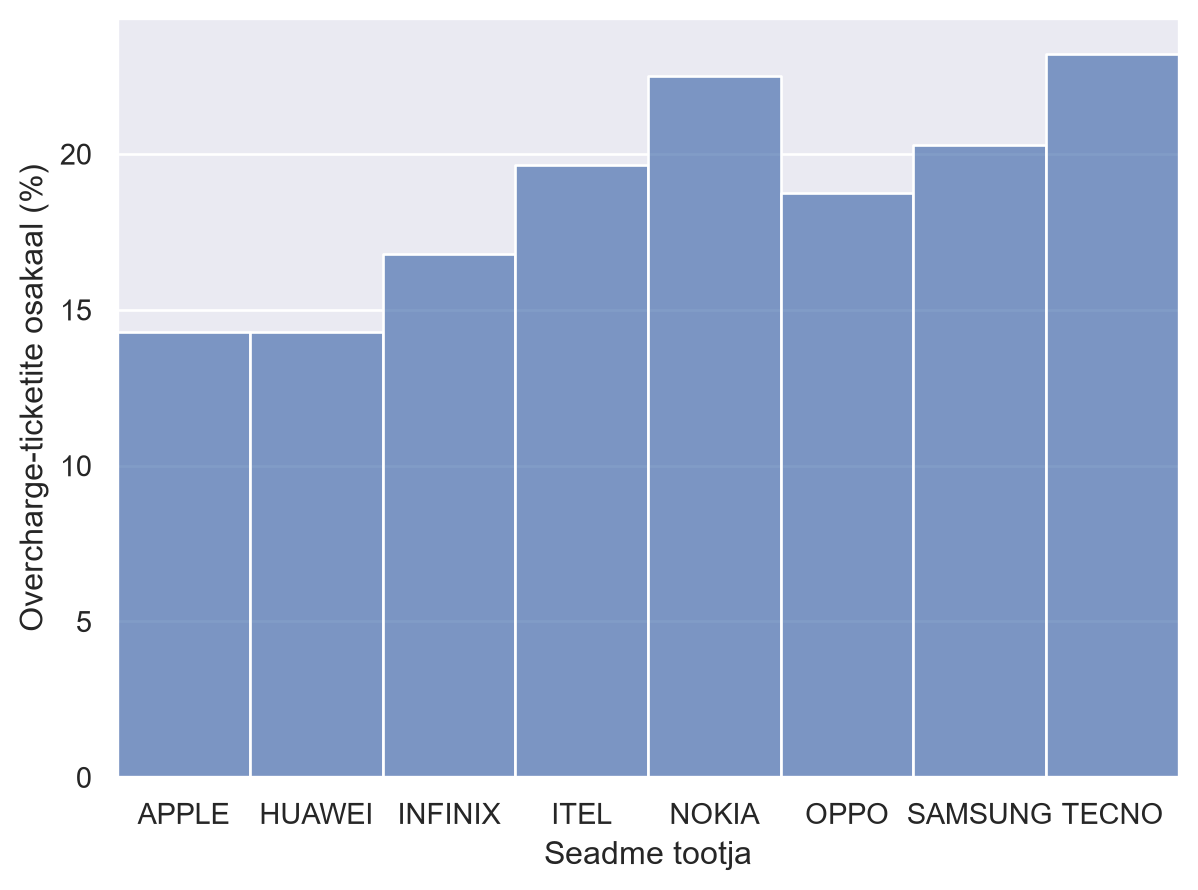

In [92]:
(
    so.Plot(
        device_osakaal_plot,
        x="device_brand",
        y="overcharge_pct"
    )
    .add(so.Bars())
    .label(
        x="Seadme tootja",
        y="Overcharge-ticketite osakaal (%)"
    )
)

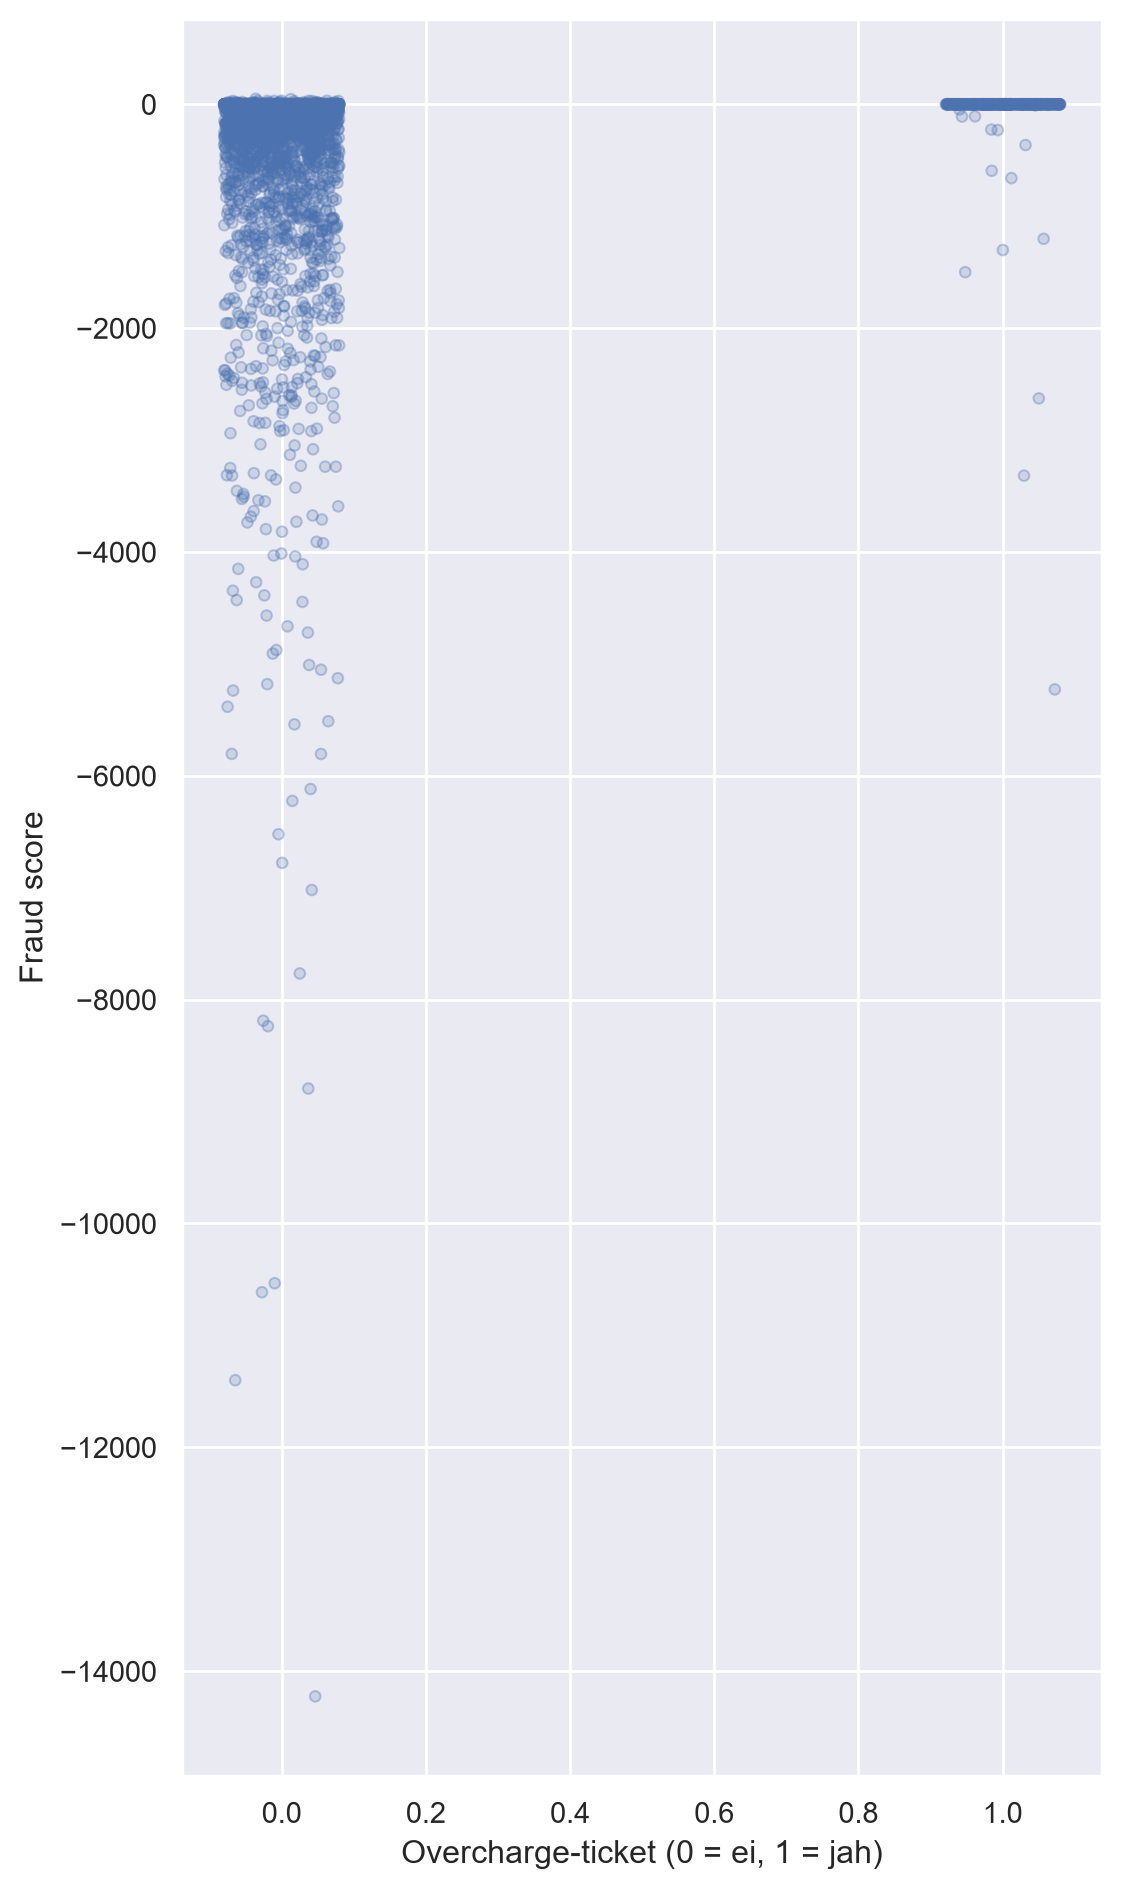

In [93]:
(
    so.Plot(
        rf_andmed,
        x="overpaid_ride_ticket",
        y="fraud_score"
    )
    .add(
        so.Dots(alpha=0.35),
        so.Jitter()
    )
    .label(
        x="Overcharge-ticket (0 = ei, 1 = jah)",
        y="Fraud score"
    )
    .layout(
        size=(6, 10)
    )
)